# Machine Learning Assignment (Semester 252)

In [1]:
import os

# Repo information
GIT_REPO = "ML-Assignment"
GIT_PATH = f"https://github.com/phngan05/ML-Assignment.git"

# Check if the repository already exists, if not clone it. If it exists, pull the latest changes.
%cd /content
if not os.path.exists(GIT_REPO):
    !git clone {GIT_PATH}
    %cd {GIT_REPO}
else:
    %cd {GIT_REPO}
    !git pull origin main


/content
Cloning into 'ML-Assignment'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 205 (delta 85), reused 110 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (205/205), 25.46 MiB | 11.84 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/ML-Assignment


In [ ]:
!pip install -qU -r requirements.txt

In [3]:
# Download the dataset
from modules import utils
utils.setup_data("blessondensil294/topic-modeling-for-research-articles")

--- Setting up Kaggle API and downloading data... ---
--- Data downloaded successfully into 'data' ---


In [6]:
import pandas as pd
df = pd.read_csv("/content/ML-Assignment/data/train.csv")
df.head()

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


## Exploratory Data Analysis

### 1. Statistics & General Analysis

In [7]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


(20972, 9)

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
label_columns = [
    "Computer Science",
    "Physics",
    "Mathematics",
    "Statistics",
    "Quantitative Biology",
    "Quantitative Finance"
]
df[label_columns].sum()

,0
Computer Science,8594
Physics,6013
Mathematics,5618
Statistics,5206
Quantitative Biology,587
Quantitative Finance,249


### 2. Class Distribution Analysis

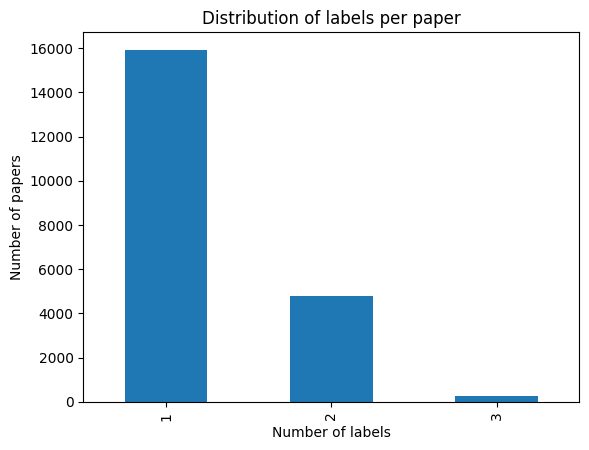

In [ ]:
from modules.visualization import visualize_labels_per_article
from modules.visualization import visualize_corr_labels
visualize_labels_per_article(df, label_columns)

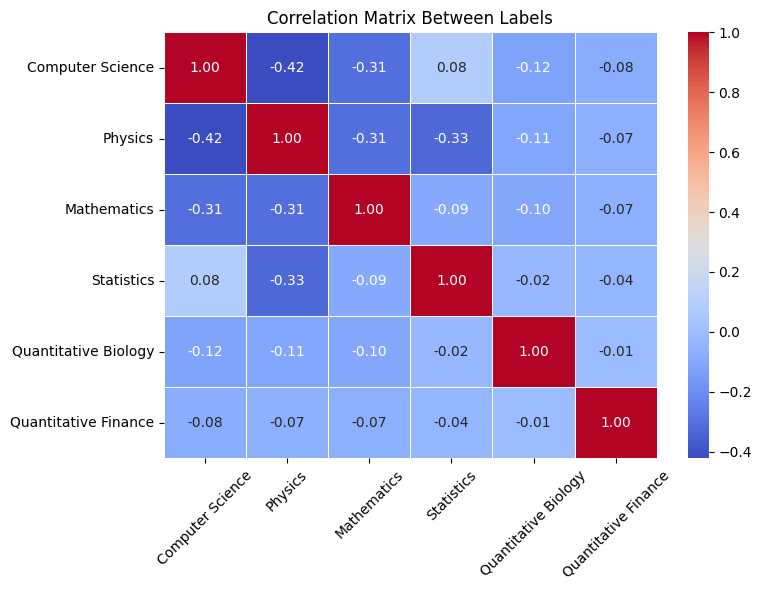

In [11]:
visualize_corr_labels(df, label_columns)

### 3. Length Analysis

In [ ]:
import nltk
from modules.calculation import calculate_text_lengths
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

calculate_text_lengths(df, 'TITLE')
calculate_text_lengths(df, 'ABSTRACT')

df.info()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             20972 non-null  int64  
 1   TITLE                          20972 non-null  object 
 2   ABSTRACT                       20972 non-null  object 
 3   Computer Science               20972 non-null  int64  
 4   Physics                        20972 non-null  int64  
 5   Mathematics                    20972 non-null  int64  
 6   Statistics                     20972 non-null  int64  
 7   Quantitative Biology           20972 non-null  int64  
 8   Quantitative Finance           20972 non-null  int64  
 9   num_labels                     20972 non-null  int64  
 10  TITLE_chars                    20972 non-null  int64  
 11  TITLE_words                    20972 non-null  int64  
 12  TITLE_mean_word_length         20972 non-null 

In [13]:
title_length_columns = ['TITLE_chars', 'TITLE_words', 'TITLE_mean_word_length', 'TITLE_mean_sentence_length']
abstract_length_columns = ['ABSTRACT_chars', 'ABSTRACT_words', 'ABSTRACT_mean_word_length', 'ABSTRACT_mean_sentence_length' ]

#### Title Analysis

In [14]:
df[title_length_columns].describe()

,TITLE_chars,TITLE_words,TITLE_mean_word_length,TITLE_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,72.897721,9.514972,7.812645,72.235310
std,26.128903,3.611493,1.246562,25.959505
min,7.000000,1.000000,3.500000,7.000000
25%,54.000000,7.000000,7.000000,54.000000
50%,71.000000,9.000000,7.714286,70.000000
75%,88.000000,12.000000,8.545455,88.000000
max,239.000000,40.000000,17.500000,239.000000


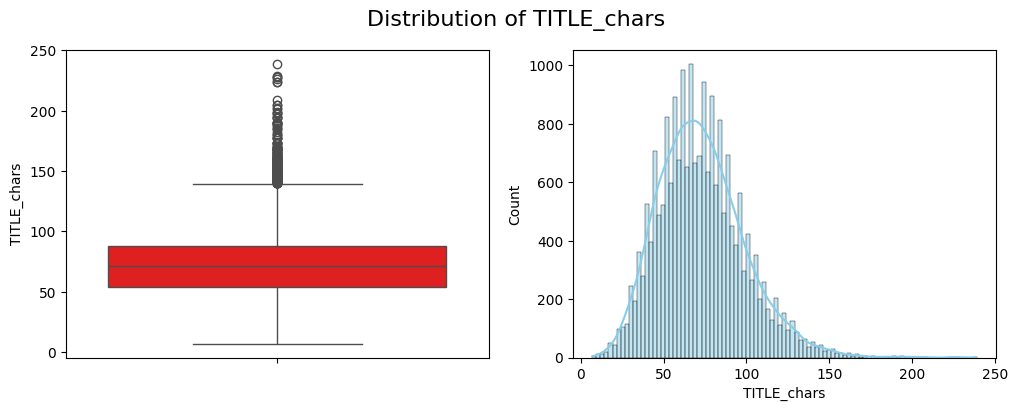

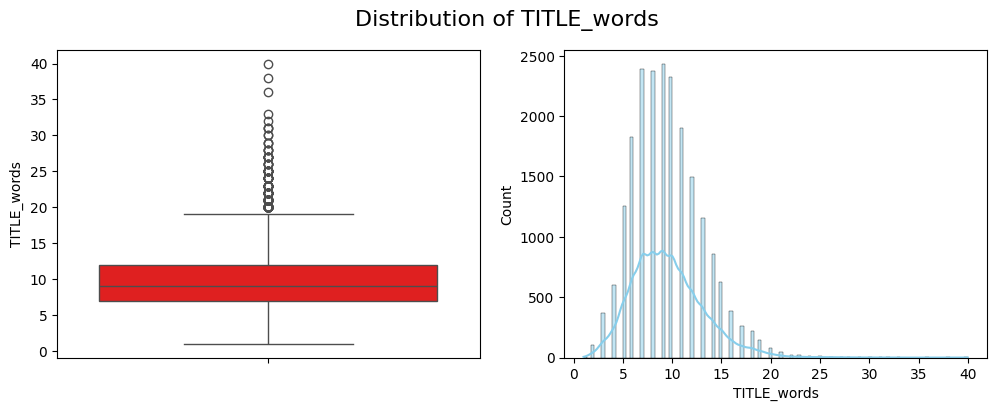

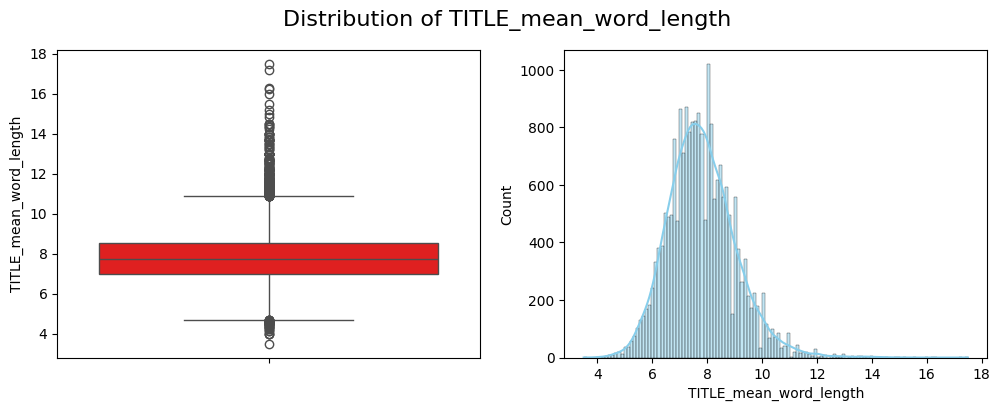

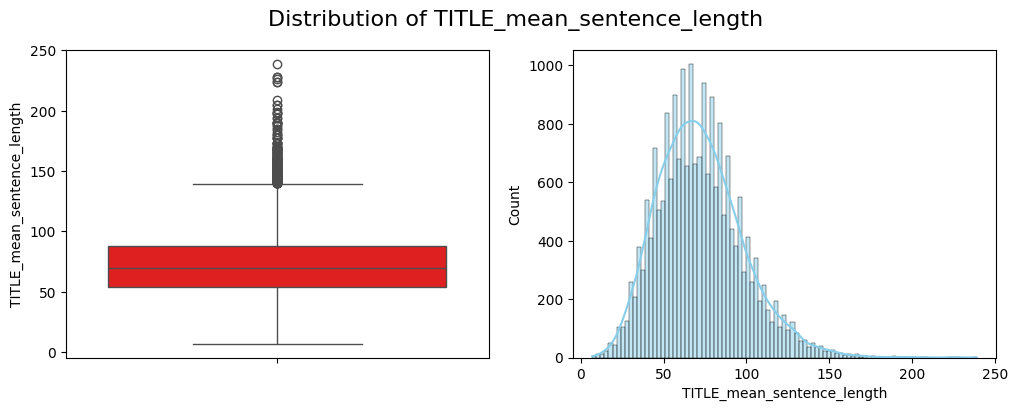

In [ ]:
from modules.visualization import visualize_text_length_distribution
for col in title_length_columns:
    visualize_text_length_distribution(df, col)

Titles are generally short and concise, with an average length of around 73 characters (around 9-10 words). Most titles fall within 50-90 characters or 7-12 words, showing a relatively consistent structure. The distributions are slightly right-skewed, with several upper outliers representing unusually long or descriptive titles. The average word length (~7-8 characters) suggests the frequent use of technical or academic vocabulary.

#### Abstract Analysis

In [16]:
df[abstract_length_columns].describe()

,ABSTRACT_chars,ABSTRACT_words,ABSTRACT_mean_word_length,ABSTRACT_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,1009.103376,148.404873,6.821117,164.264092
std,408.641363,60.781306,0.466272,46.169121
min,7.000000,1.000000,4.052239,6.000000
25%,714.000000,104.000000,6.532609,137.000000
50%,989.000000,145.000000,6.806857,158.250000
75%,1290.000000,190.000000,7.090332,184.250000
max,2761.000000,449.000000,19.270270,1324.000000


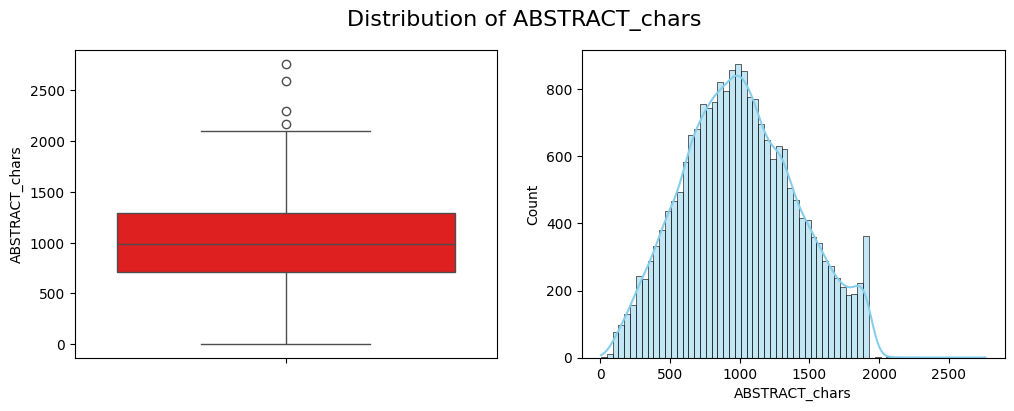

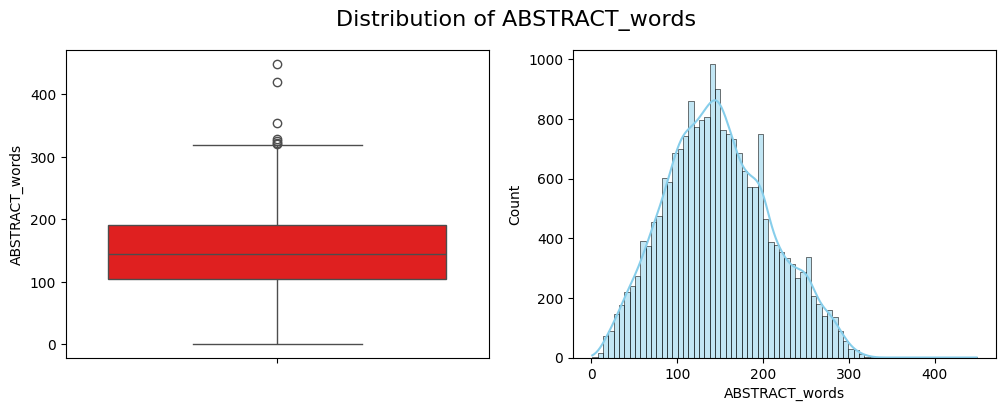

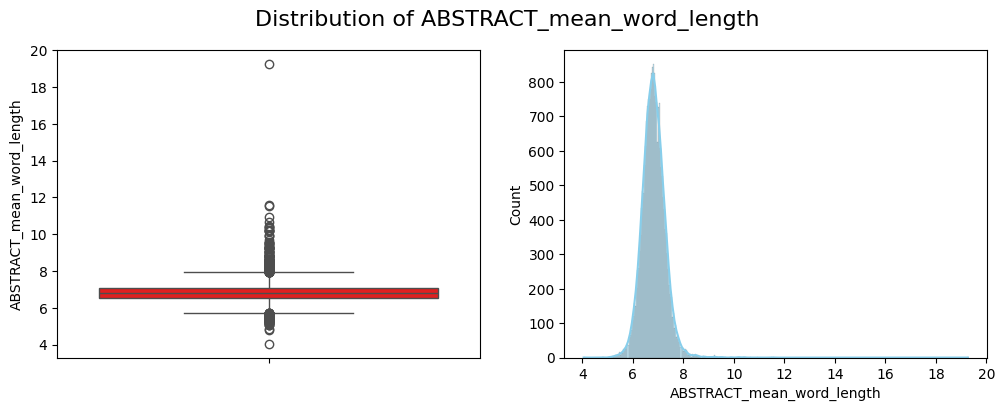

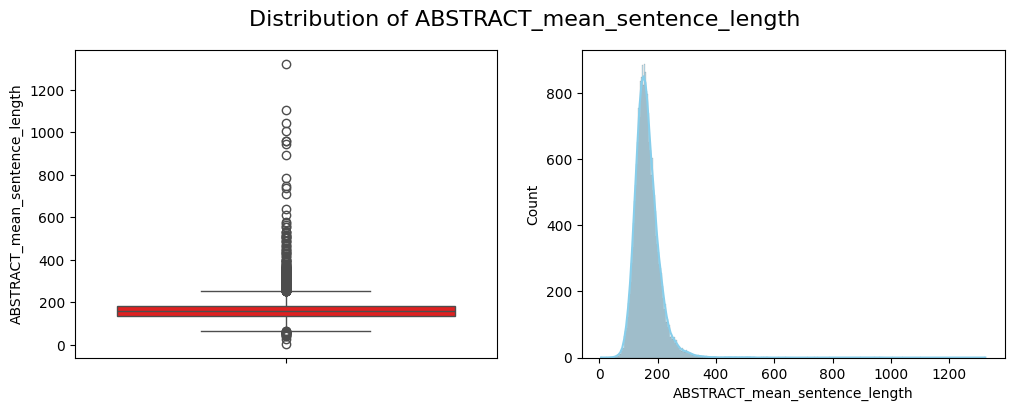

In [17]:
for col in abstract_length_columns:
    visualize_text_length_distribution(df, col)

Abstracts are significantly longer and more variable than titles, averaging around 1000 characters (around 148 words). Most abstracts fall between 500-1500 characters or 100-200 words, which aligns with typical academic writing conventions. Sentence lengths are mostly concentrated around 100-200 characters, though some extreme outliers indicate either highly complex sentences or formatting inconsistencies. The average word length (~6-7 characters) also reflects the use of technical terminology.

  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH
Chuyên ngành               Số bài  Title (từ)  Title (ký tự)  Abstract (từ)  Abstract (ký tự)
--------------------------------------------------------------------------------
Computer Science            8,594         9.0           69.9          159.1            1081.9
Physics                     6,013        10.7           80.7          161.4            1096.2
Mathematics                 5,618         9.0           68.2          113.7             769.8
Statistics                  5,206         8.9           70.5          155.6            1068.4
Quantitative Biology          587        10.6           81.8          177.7            1232.2
Quantitative Finance          249         9.7           73.0          140.6             946.0


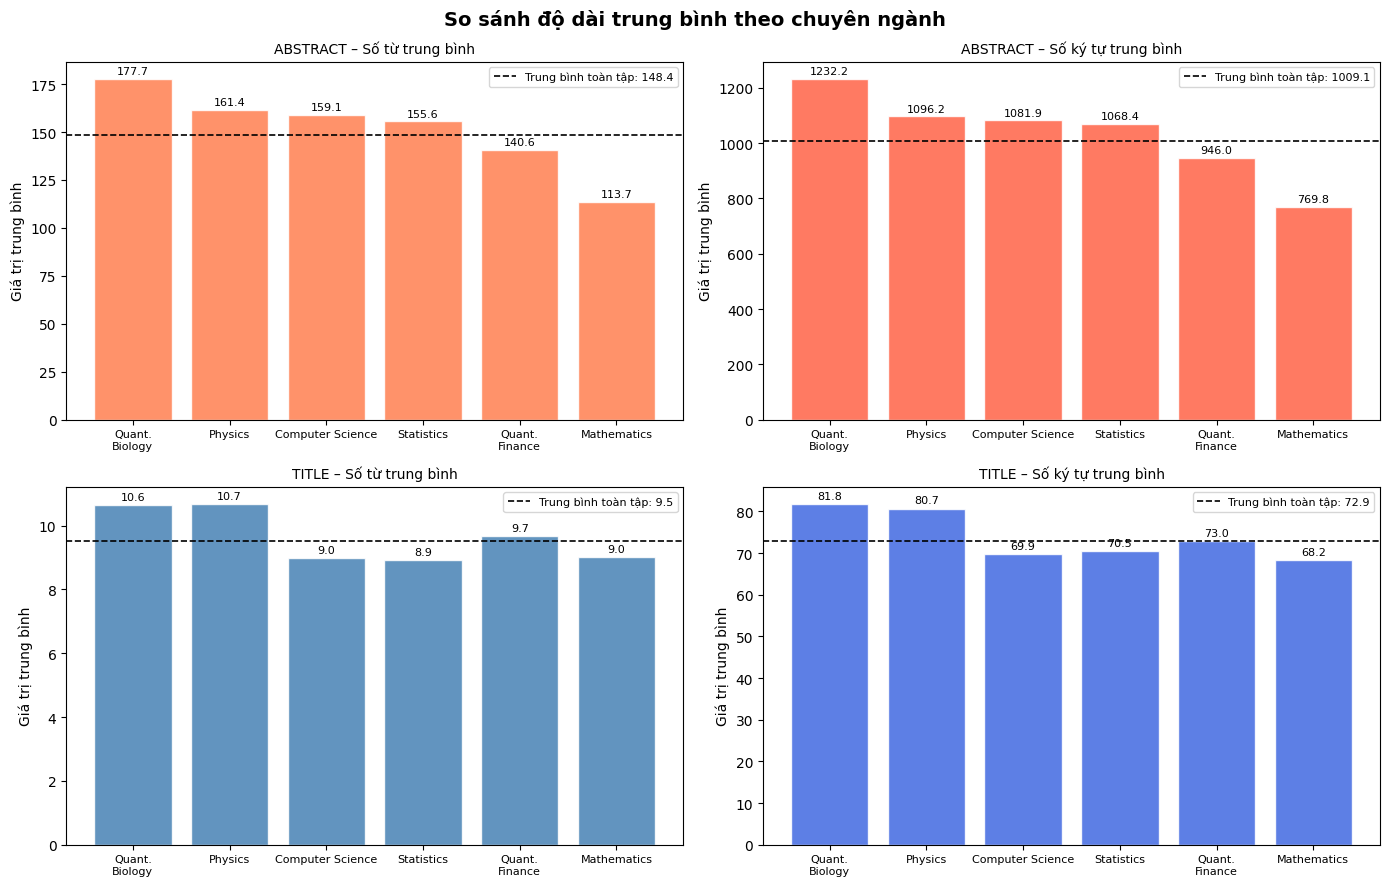


--- Nhận xét ---
Abstract dài nhất (số từ) : Quantitative Biology (177.7 từ/bài)
Abstract ngắn nhất (số từ): Mathematics (113.7 từ/bài)
Title dài nhất  (số từ)   : Physics (10.7 từ/bài)
Title ngắn nhất (số từ)   : Statistics (8.9 từ/bài)


In [ ]:
from modules.calculation import calculate_length_by_label
from modules.visualization import visualize_length_by_label

# Calculate average length by field
summary = calculate_length_by_label(df, label_columns)

# Visualization
visualize_length_by_label(summary, df)

## Preprocessing

### 1. Outlier Removal

EDA-based (IQR × 1.5):
- **ABSTRACT_words**: lower fence ≈ −25 → use practical threshold **20 words**; upper fence ≈ 319 → use **320 words**
- **TITLE_words**: lower fence ≈ −0.5 → use practical threshold **3 words**; upper fence ≈ 19.5 → use **20 words**

Lower bound for removing nearly empty abstracts (eg: *"Yes."*), upper bound for removing unusually long abstracts.

In [ ]:
print(f"Number of rows before outlier removal: {len(df):,}")

# Threshold defined from EDA (IQR × 1.5)
ABSTRACT_MIN_WORDS = 20
ABSTRACT_MAX_WORDS = 320
TITLE_MIN_WORDS    = 3
TITLE_MAX_WORDS    = 20

mask = (
    (df["ABSTRACT_words"] >= ABSTRACT_MIN_WORDS) &
    (df["ABSTRACT_words"] <= ABSTRACT_MAX_WORDS) &
    (df["TITLE_words"]    >= TITLE_MIN_WORDS)    &
    (df["TITLE_words"]    <= TITLE_MAX_WORDS)
)

df_clean = df[mask].reset_index(drop=True)

print(f"Number of rows after outlier removal : {len(df_clean):,}")
print(f"Number of rows removed              : {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")
print()
df_clean[["ABSTRACT_words", "TITLE_words"]].describe().round(1)

Số dòng trước khi loại outlier: 20,972
Số dòng sau khi loại outlier : 20,625
Số dòng bị loại              : 347 (1.65%)



,ABSTRACT_words,TITLE_words
count,20625.0,20625.0
mean,148.8,9.5
std,60.0,3.4
min,20.0,3.0
25%,105.0,7.0
50%,145.0,9.0
75%,190.0,12.0
max,319.0,20.0


### 2. Lowercase


In [ ]:
# Combine TITLE + ABSTRACT into a single text column
df_clean["text"] = df_clean["TITLE"] + " " + df_clean["ABSTRACT"]

# Convert to lowercase
df_clean["text"] = df_clean["text"].str.lower()

# Check
print("Before:")
print(df_clean["TITLE"].iloc[0])
print("\nAfter (text):")
print(df_clean["text"].iloc[0][:200])

Trước:
Reconstructing Subject-Specific Effect Maps

Sau (text):
reconstructing subject-specific effect maps   predictive models allow subject-specific inference when analyzing disease
related alterations in neuroimaging data. given a subject's data, inference can



### 3. Remove special characters, punctuation and extra space

In [ ]:
from modules.preprocessing import remove_noise

df_clean["text"] = df_clean["text"].apply(remove_noise)

# Check
print("After removing special characters / numbers / extra spaces:")
print(df_clean["text"].iloc[0][:300])


Sau khi loại ký tự đặc biệt / số / khoảng trắng thừa:
reconstructing subject specific effect maps predictive models allow subject specific inference when analyzing disease related alterations in neuroimaging data given a subject s data inference can be made at two levels global i e identifiying condition presence for the subject and local i e detecting


### 4. Remove Stopwords

In [ ]:
from modules.preprocessing import remove_stopwords

df_clean["text_clean"] = df_clean["text"].apply(remove_stopwords)

# Check
print(f"Average number of words before removing stopwords: {df_clean['text'].str.split().str.len().mean():.1f}")
print(f"Average number of words after removing stopwords: {df_clean['text_clean'].str.split().str.len().mean():.1f}")
print()
print("Example after removing stopwords:")
print(df_clean["text_clean"].iloc[0][:300])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Số từ trung bình trước khi loại stopwords: 160.0
Số từ trung bình sau khi loại stopwords  : 97.0

Ví dụ sau khi loại stopwords:
reconstructing subject specific effect maps predictive models allow subject specific inference analyzing disease related alterations neuroimaging data given subject data inference made two levels global identifiying condition presence subject local detecting condition effect individual measurement e


### 5. Top 20 most frequent words

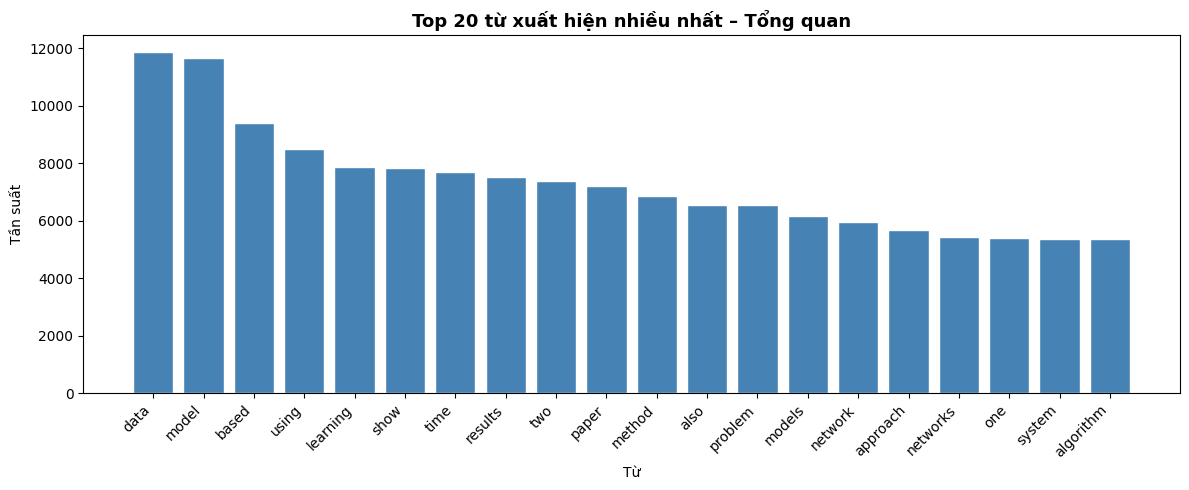

Từ                     Tần suất
--------------------------------
data                     11,850
model                    11,646
based                     9,400
using                     8,503
learning                  7,873
show                      7,827
time                      7,701
results                   7,503
two                       7,386
paper                     7,211
method                    6,851
also                      6,560
problem                   6,556
models                    6,165
network                   5,940
approach                  5,685
networks                  5,440
one                       5,384
system                    5,378
algorithm                 5,368


In [ ]:
from modules.visualization import visualize_frequency

visualize_frequency(df_clean, "text_clean")

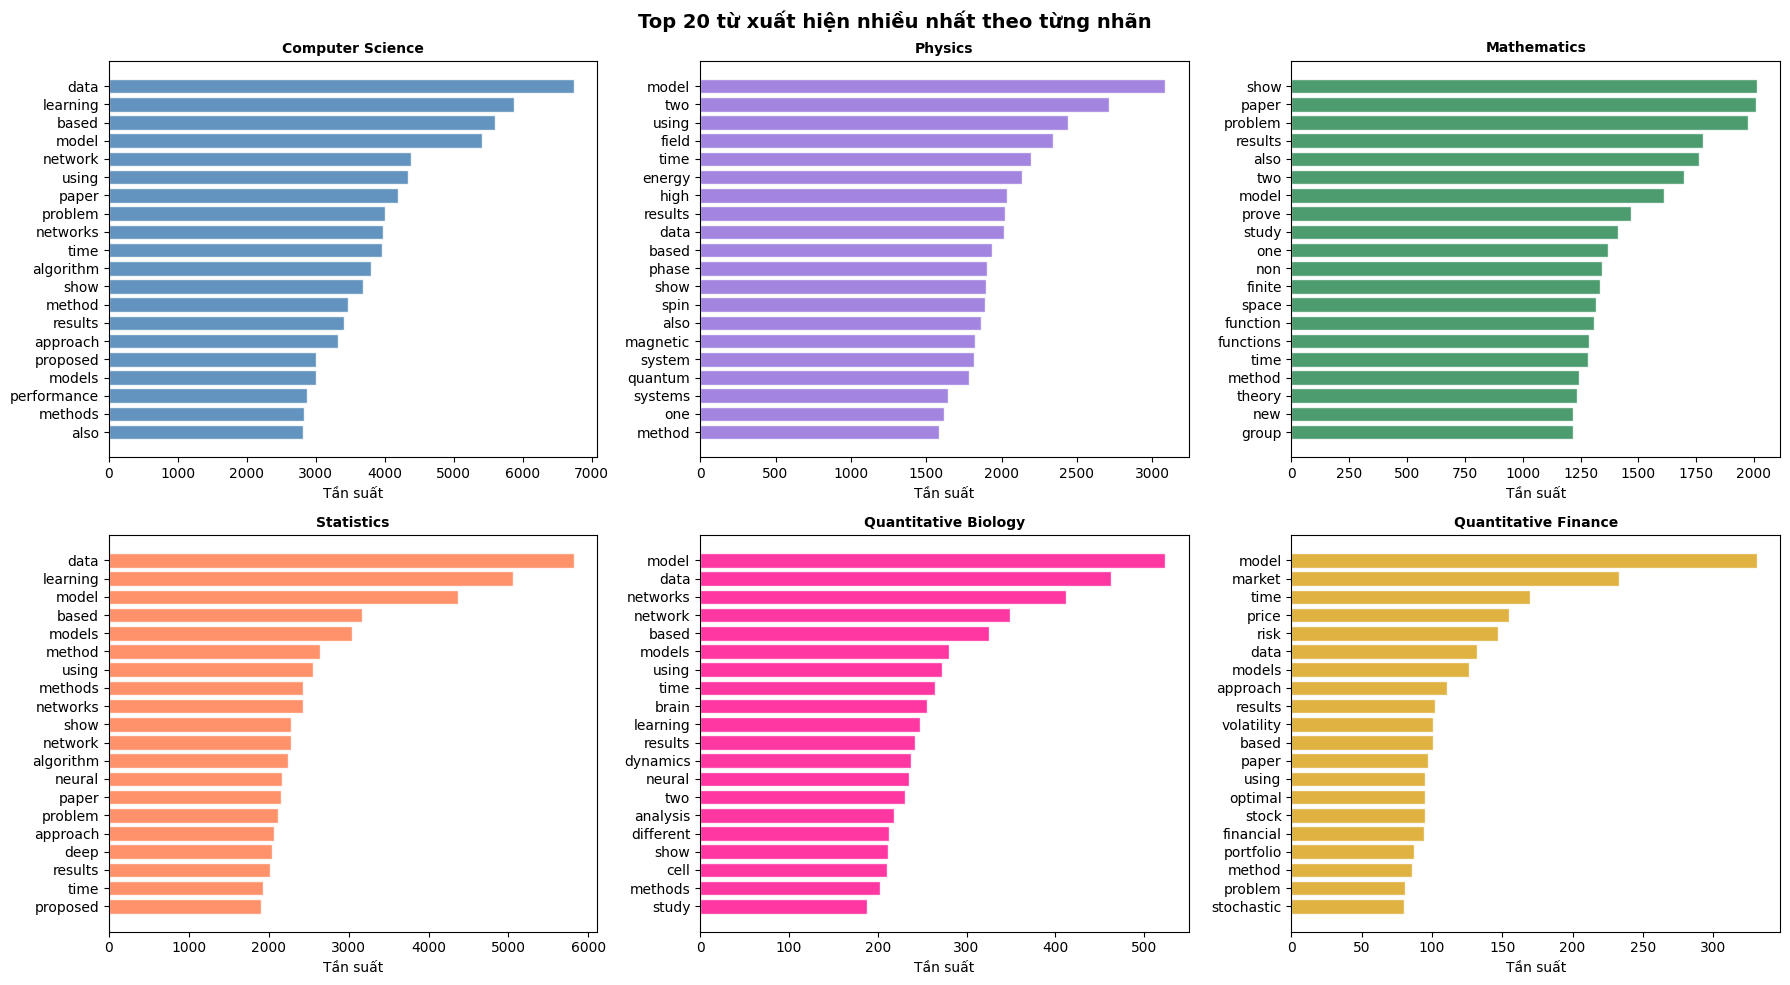

In [ ]:
from modules.visualization import visualize_frequency_by_label

visualize_frequency_by_label(df_clean, label_columns)

### 6. WordCloud theo Từng Nhãn

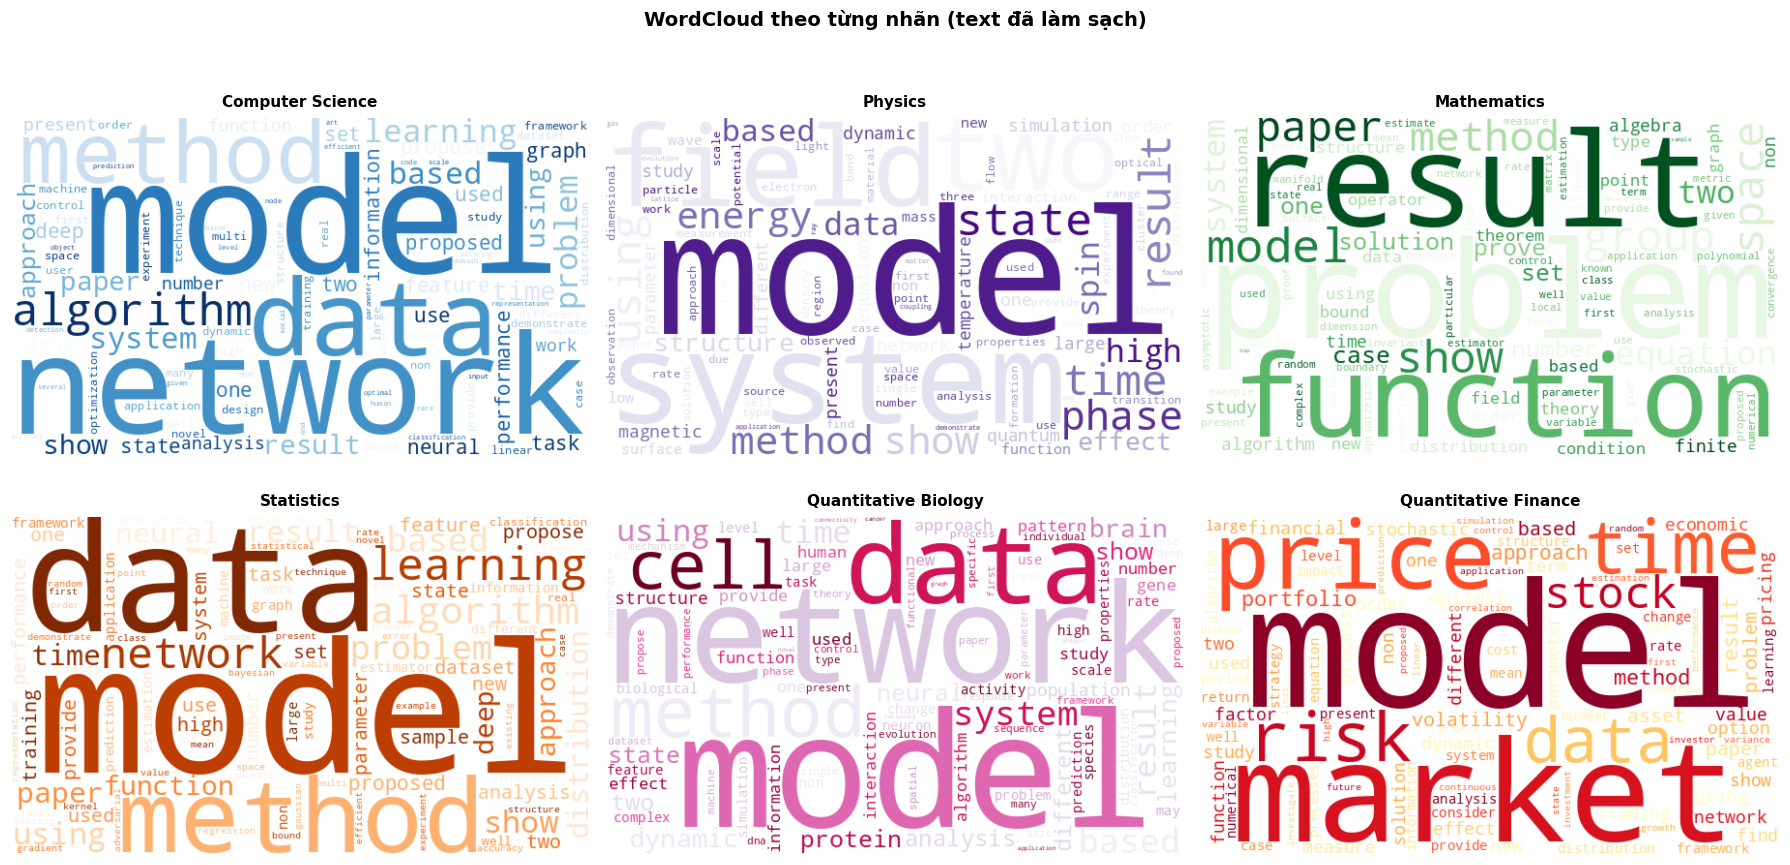

In [ ]:
from modules.visualization import visualize_wordcloud
visualize_wordcloud(df_clean, label_columns)

### 7. Lemmatization

In [26]:
# Take about 3 minutes :((
from modules import preprocessing

df_clean['lemma_text'] = preprocessing.lemma_data(df_clean, 'text_clean')

In [27]:
print("========== BEFORE LEMMATIZATION ==========")
print(df_clean['text_clean'].head())

print("\n\n========== AFTER LEMMATIZATION ==========")

print(df_clean['lemma_text'].head())


========== BEFORE LEMMATIZATION ==========
0    reconstructing subject specific effect maps pr...
1    rotation invariance neural network rotation in...
2    spherical polyharmonics poisson kernels polyha...
3    finite element approximation stochastic maxwel...
4    comparative study discrete wavelet transforms ...
Name: text_clean, dtype: object


========== AFTER LEMMATIZATION ==========
0    reconstruct subject specific effect map predic...
1    rotation invariance neural network rotation in...
2    spherical polyharmonic poisson kernel function...
3    element approximation stochastic stochastic co...
4    comparative study discrete wavelet transform w...
Name: lemma_text, dtype: object


In [ ]:
print(f"Average number of words before lemmatization  : {df_clean['text_clean'].str.split().str.len().mean():.1f}")
print(f"Average number of words after lemmatization  : {df_clean['lemma_text'].str.split().str.len().mean():.1f}")

Số từ trung bình trước lemmatization  : 97.0
Số từ trung bình sau lemmatization  : 85.6


### 8. Bi-gram Analysis

/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarnin

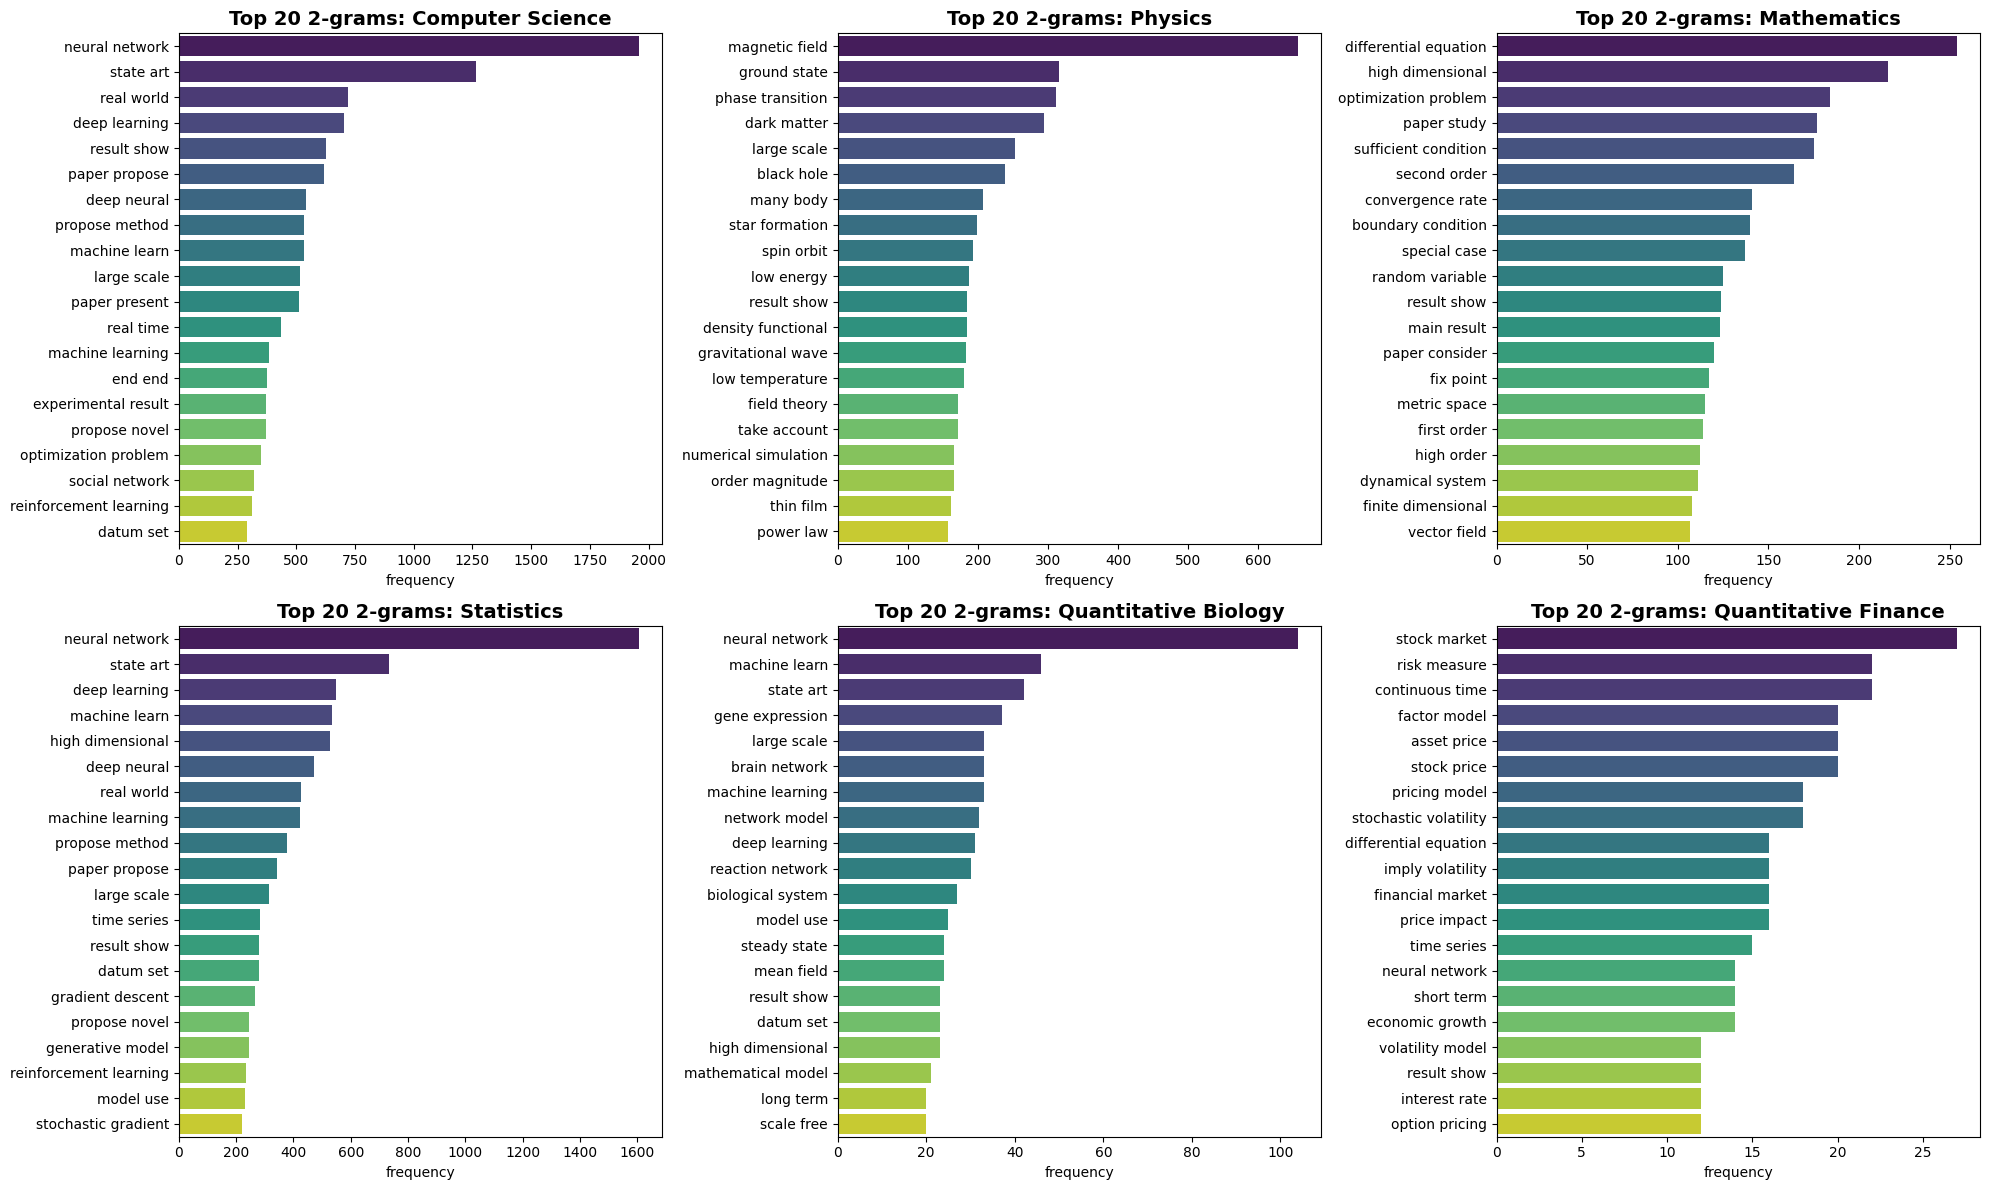

In [ ]:
from modules import visualization
labels = ['Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

# Bi-gram
visualization.visualize_ngram(df_clean, labels, 2)

# Tri-gram
visualization.visualize_ngram(df_clean, labels, 3)


## Feature Extraction

### 1. Tradition Embedding

In [31]:
# ============================================================
# FEATURE EXTRACTION
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import stopwords
import numpy as np
import pickle
from scipy.sparse import save_npz

# Custom stopwords = NLTK stopwords + domain stopwords
custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update({
    "use", "used", "using", "show", "shown", "result", "results",
    "method", "methods", "approach", "approaches", "based", "paper",
    "propose", "proposed", "study", "studies"
})

# Chọn cột text sau preprocessing
if 'lemma_text' in df_clean.columns:
    text_column = 'lemma_text'


X = df_clean[text_column]
y = df_clean[['Computer Science', 'Physics', 'Mathematics', 'Statistics',
              'Quantitative Biology', 'Quantitative Finance']]

print(f"Data shape: {len(X):,} samples, {y.shape[1]} labels")
print(f"Using column: '{text_column}'")

Data shape: 20,625 samples, 6 labels
Using column: 'lemma_text'


#### Bag of Words

In [32]:
# ============================================================
# 1. BAG OF WORDS (CountVectorizer)
# ============================================================
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words=list(custom_stopwords)
)

X_bow = count_vectorizer.fit_transform(X)

print("BAG OF WORDS")
print("="*60)
print(f"Shape: {X_bow.shape}")
print(f"Sparsity: {(1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100:.2f}%")



BAG OF WORDS
Shape: (20625, 5000)
Sparsity: 98.89%


#### TF-IDF

In [33]:
# ============================================================
# 2. TF-IDF - IMPROVED
# ============================================================
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=list(custom_stopwords)
)

X_tfidf = tfidf_vectorizer.fit_transform(X)

print("TF-IDF")
print("="*60)
print(f"Shape: {X_tfidf.shape}")
print(f"Sparsity: {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")



TF-IDF
Shape: (20625, 5000)
Sparsity: 98.89%


In [ ]:
from modules.feature_extraction import show_feature_extraction_top

# So sánh giữa 2 phương pháp feature extraction
doc_idx = 0
print(f"Document #{doc_idx}: {df_clean['TITLE'].iloc[doc_idx]}\n")

# ===== BoW =====
show_feature_extraction_top(count_vectorizer, "Bow", X_bow, doc_idx=doc_idx)

# ===== TF-IDF =====
show_feature_extraction_top(tfidf_vectorizer, "TF-IDF", X_bow, doc_idx=doc_idx)


Document #0: Reconstructing Subject-Specific Effect Maps

BoW - Top 5:
  1. subject              → 8
  2. datum                → 7
  3. specific             → 6
  4. detection            → 5
  5. classifier           → 4

TF-IDF - Top 5:
  1. subject              → 0.2396
  2. alzheimer            → 0.2063
  3. neuroimage           → 0.2054
  4. classifier           → 0.1943
  5. disease              → 0.1879


/tmp/ipykernel_15765/3460729734.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='viridis', ax=axes[0])


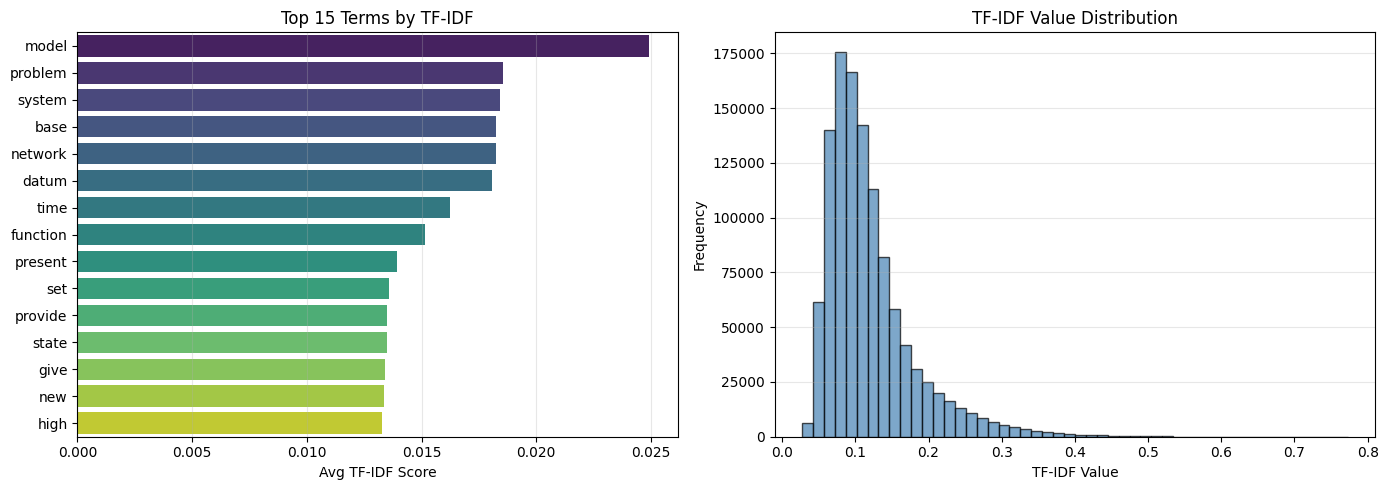

TF-IDF stats: min=0.0271, max=0.7730, mean=0.1195


In [ ]:
# ============================================================
# VISUALIZATION: TF-IDF Distribution
# ============================================================
from modules.visualization import visualize_tfidf_top
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

# Top 15 terms
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_15 = mean_tfidf.argsort()[-15:][::-1]
top_words = [feature_names_tfidf[i] for i in top_15]
top_scores = [mean_tfidf[i] for i in top_15]

visualize_tfidf_top(top_scores, top_words, X_tfidf)

In [36]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Save BoW
with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(count_vectorizer, f)
save_npz('X_bow.npz', X_bow)

# Save TF-IDF (recommended for training)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
save_npz('X_tfidf.npz', X_tfidf)

# Save labels
y.to_csv('y_labels.csv', index=False)

print("✓ Saved:")
print("  - bow_vectorizer.pkl, X_bow.npz")
print("  - tfidf_vectorizer.pkl, X_tfidf.npz")
print("  - y_labels.csv")
print(f"\nFeatures shape: {X_tfidf.shape}")
print(f"Labels shape: {y.shape}")
print("\n→ Ready for model training!")

✓ Saved:
  - bow_vectorizer.pkl, X_bow.npz
  - tfidf_vectorizer.pkl, X_tfidf.npz
  - y_labels.csv

Features shape: (20625, 5000)
Labels shape: (20625, 6)

→ Ready for model training!


### Deep Embedding
---

**Steps:**
1. **Feature Extraction:** Use Pre-trained Model (SciBERT).
2. **Storage:** Save feature (`.npy`).

---
*Note: Convert to **GPU** Runtime for accelerating this process.*


In [37]:
#lấy lại kết quả EDA để lựa làm giới hạn cho mô hình BERT (xử lí được tối đa 512 từ)

ABSTRACT_MIN_WORDS = 20
ABSTRACT_MAX_WORDS = 320
TITLE_MIN_WORDS    = 3
TITLE_MAX_WORDS    = 20

mask = (
    (df["ABSTRACT_words"] >= ABSTRACT_MIN_WORDS) &
    (df["ABSTRACT_words"] <= ABSTRACT_MAX_WORDS) &
    (df["TITLE_words"]    >= TITLE_MIN_WORDS)    &
    (df["TITLE_words"]    <= TITLE_MAX_WORDS)
)

df_bert = df[mask].reset_index(drop=True)

df_bert['combined_text'] = df_bert['TITLE'] + " [SEP] " + df_bert['ABSTRACT']
df_bert['combined_text'].head()

,combined_text
0,Reconstructing Subject-Specific Effect Maps [S...
1,Rotation Invariance Neural Network [SEP] Rot...
2,Spherical polyharmonics and Poisson kernels fo...
3,A finite element approximation for the stochas...
4,Comparative study of Discrete Wavelet Transfor...


In [ ]:
import torch
import numpy as np
from modules.feature_extraction import extract_embeddings


# Config
model_names = ['bert-base-uncased', 'allenai/scibert_scivocab_uncased']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
max_length = 256 # Độ dài bạn đã tính toán từ bước EDA

# Execute
document_list = df_bert['combined_text'].astype(str).tolist()

# Extract General BERT
print("--- Stage 1: General BERT ---")
general_feats = extract_embeddings(document_list, model_names[0])
np.save('general_embeddings.npy', general_feats)

# Trích xuất SciBERT
print("\n--- Stage 2: SciBERT ---")
science_feats = extract_embeddings(document_list, model_names[1])
np.save('science_embeddings.npy', science_feats)

# 4. Gộp và Lưu bản cuối
print("\n--- Stage 3: Feature Combination ---")
final_embeddings = np.hstack([general_feats, science_feats])
np.save('combined_features.npy', final_embeddings)

print(f"Finished! Vector size: {final_embeddings.shape}")


--- Giai đoạn 1: General BERT ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  4%|▍         | 7/162 [00:15<05:34,  2.16s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

sci_emb = np.load('science_embeddings.npy')
general_emb = np.load('general_embeddings.npy')
X = np.hstack([general_emb, sci_emb])
y = df_bert[label_columns].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Học tỉ lệ từ tập Train và áp dụng luôn
X_test = scaler.transform(X_test)       # Chỉ áp dụng tỉ lệ đã học vào tập Test

model = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual=False)) # dual=False giúp chạy nhanh hơn khi n_samples > n_features
model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import f1_score, classification_report
y_pred = model.predict(X_test)
print("F1 Score (Micro):", f1_score(y_test, y_pred, average='micro'))
print("\nChi tiết từng nhãn:")
print(classification_report(y_test, y_pred, target_names=label_columns))

In [ ]:
print("abc")

## Training & Modeling

### 1. Traditional Machine Learning Feature

### 2. Deep Learning Feature

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier

# Load combined embeddings (BERT + SciBERT, shape: n_samples x 1536)
X_dl = np.load('combined_features.npy')
y_dl = df_bert[label_columns].values

print(f"Feature matrix : {X_dl.shape}")
print(f"Label matrix   : {y_dl.shape}")
print(f"Labels         : {label_columns}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42
)

# Chuẩn hóa - LinearSVC nhạy cảm với scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain : {X_train_sc.shape}")
print(f"Test  : {X_test_sc.shape}")

### Traditional Model

In [ ]:
from modules.model import train_and_predict, evaluate_model

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

print("=" * 60)
print("MÔ HÌNH 1: LinearSVC + Deep Learning Features")
print("=" * 60)

lsvc = OneVsRestClassifier(
    LinearSVC(C=1.0, class_weight='balanced', dual=False,
              max_iter=2000, random_state=42)
)

lsvc, y_pred_lsvc = train_and_predict(lsvc, dataset = (X_train_sc, y_train, X_test_sc, y_test), label_columns=label_columns)

# Evaluation
evaluate_model(y_pred=y_pred_lsvc, y_test=y_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

print("=" * 60)
print("MÔ HÌNH 2: Random Forest + Deep Learning Features")
print("=" * 60)

rf = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=50,
            class_weight='balanced_subsample',  
            n_jobs=1,       
            random_state=42
        ),
        n_jobs=-1 
    )

rf, y_pred_rf = train_and_predict(rf, dataset = (X_train_sc, y_train, X_test_sc, y_test), label_columns=label_columns)

evaluate_model(y_pred=y_pred_rf, y_test=y_test)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# OvR predict_proba trả về shape (n_samples, 6), mỗi cột là prob của class dương
proba_matrix = rf.predict_proba(X_test_sc)  # shape: (n_samples, 6)

thresholds = []
for i in range(6):
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.1, 0.6, 0.05):
        pred = (proba_matrix[:, i] > t).astype(int)
        f = f1_score(y_test[:, i], pred, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    thresholds.append(best_t)

print("Ngưỡng tối ưu theo từng nhãn:")
for name, t in zip(label_columns, thresholds):
    print(f"  {name:<25} → {t:.2f}")

y_pred_rf_tuned = np.column_stack([
    (proba_matrix[:, i] > thresholds[i]).astype(int)
    for i in range(6)
])

print(f"\nSau khi tuning ngưỡng:")
# Evaluation after tuning
evaluate_model(y_pred=y_pred_rf_tuned, y_test=y_test)


In [ ]:
import pandas as pd
from modules.visualization import visualize_models_comparation

results = pd.DataFrame({
    'Model': ['LinearSVC', 'Random Forest'],
    'Micro-F1': [
        f1_score(y_test, y_pred_lsvc, average='micro'),
        f1_score(y_test, y_pred_rf,   average='micro'),
    ],
    'Macro-F1': [
        f1_score(y_test, y_pred_lsvc, average='macro'),
        f1_score(y_test, y_pred_rf,   average='macro'),
    ],
})

print("=== So sánh mô hình (Deep Learning Features) ===")
print(results.to_string(index=False))

visualize_models_comparation(results)



#### Deep Learning Model
---
**Fine-tune BERT**

In [42]:
!pip install transformers[torch] datasets


In [47]:
from datasets import Dataset
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Hàm xử lý dữ liệu
def tokenize_and_encode(examples):
    texts = [t + " [SEP] " + a for t, a in zip(examples['TITLE'], examples['ABSTRACT'])]
    tokenized = tokenizer(texts, padding="max_length", truncation=True, max_length=256)

    # Nhãn phải ở dạng float cho bài toán Multi-label
    labels = []
    cols = ['Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']
    for i in range(len(examples['TITLE'])):
        label_row = [float(examples[col][i]) for col in cols]
        labels.append(label_row)

    tokenized["labels"] = labels
    return tokenized

ds = Dataset.from_pandas(df)
ds = ds.map(tokenize_and_encode, batched=True, remove_columns=ds.column_names)
ds = ds.train_test_split(test_size = 0.2)

Map:   0%|          | 0/20972 [00:00<?, ? examples/s]

In [48]:
# 3. Tải mô hình với cấu hình đa nhãn
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    problem_type="multi_label_classification"
).to("cuda")

# 4. Thiết lập tham số huấn luyện
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,              # Fine-tuning thường chỉ cần 3-5 epoch
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,              # LR rất nhỏ để tránh phá hỏng trọng số pre-trained
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True                        # Sử dụng GPU tăng tốc
)

# 5. Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["test"]
)

# 6. Bắt đầu Fine-tuning
trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss
1,No log,0.162691


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,No log,0.162691
2,0.186757,0.153493
3,0.186757,0.155854
4,0.117786,0.159399
5,0.117786,0.163366


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1315, training_loss=0.1381351703020103, metrics={'train_runtime': 1149.078, 'train_samples_per_second': 73.002, 'train_steps_per_second': 1.144, 'total_flos': 1.103593177391616e+16, 'train_loss': 0.1381351703020103, 'epoch': 5.0})

In [ ]:
import torch.nn as nn
from transformers import Trainer

# 1. Tính toán trọng số dựa trên tần suất nhãn (ví dụ định lượng)
# Trọng số = Tổng số mẫu / (Số nhãn * Số mẫu của nhãn đó)
# Dựa trên support của bạn: CS(1703), Bio(115), Finance(49)...
# Ta có thể thiết lập thủ công để ưu tiên cực độ cho Bio và Finance:
weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 15.0, 30.0]).to("cuda")

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Sử dụng BCEWithLogitsLoss với pos_weight
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Sau đó bạn dùng CustomTrainer thay vì Trainer thông thường
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["test"]
)
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.245264
2,0.151902,0.232240
3,0.151902,0.289147
4,0.098617,0.301325


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# Dự đoán
predictions = trainer.predict(ds["test"])
# Áp dụng hàm Sigmoid vì đầu ra là logits
preds = torch.sigmoid(torch.from_numpy(predictions.predictions)).numpy()
# Ngưỡng 0.5 để quyết định nhãn
y_pred = (preds > 0.5).astype(int)
y_true = np.array(ds["test"]["labels"])

# Đánh giá định lượng
print("Macro F1:", f1_score(ds["test"]["labels"], y_pred, average='macro'))
print("Micro F1:", f1_score(ds["test"]["labels"], y_pred, average='micro'))


Macro F1: 0.7664443755784666
Micro F1: 0.8500948766603416


In [58]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Lấy xác suất dự báo từ tập Test
predictions = trainer.predict(ds["test"])
probs = torch.sigmoid(torch.from_numpy(predictions.predictions)).numpy()
y_true = np.array(ds["test"]["labels"])

# 2. Hàm tìm ngưỡng tối ưu cho từng cột
best_thresholds = []
for i in range(6): # 6 nhãn
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.1, 0.9, 0.01): # Thử các ngưỡng từ 0.1 đến 0.9
        current_f1 = f1_score(y_true[:, i], (probs[:, i] > thresh).astype(int))
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh
    best_thresholds.append(best_thresh)

# 3. Áp dụng ngưỡng mới
y_pred_final = np.zeros_like(probs)
for i in range(6):
    y_pred_final[:, i] = (probs[:, i] > best_thresholds[i]).astype(int)

# 4. In kết quả mới
target_names = ['CS', 'Physics', 'Math', 'Stats', 'Bio', 'Finance']
print("Ngưỡng tối ưu tìm được:", dict(zip(target_names, np.round(best_thresholds, 2))))
print("\nBáo cáo sau khi tối ưu ngưỡng & Weighted Loss:")
print(classification_report(y_true, y_pred_final, target_names=target_names))


Ngưỡng tối ưu tìm được: {'CS': np.float64(0.47), 'Physics': np.float64(0.5), 'Math': np.float64(0.66), 'Stats': np.float64(0.34), 'Bio': np.float64(0.12), 'Finance': np.float64(0.54)}

Báo cáo sau khi tối ưu ngưỡng & Weighted Loss:
              precision    recall  f1-score   support

          CS       0.82      0.92      0.87      1703
     Physics       0.94      0.89      0.91      1225
        Math       0.88      0.82      0.85      1125
       Stats       0.75      0.89      0.81      1009
         Bio       0.52      0.79      0.63       115
     Finance       0.80      0.65      0.72        49

   micro avg       0.83      0.88      0.85      5226
   macro avg       0.79      0.82      0.80      5226
weighted avg       0.84      0.88      0.86      5226
 samples avg       0.87      0.90      0.87      5226



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [57]:
from sklearn.metrics import f1_score, classification_report
print("\nChi tiết từng nhãn:")
print(classification_report(ds["test"]["labels"], y_pred, target_names=label_columns))


Chi tiết từng nhãn:
                      precision    recall  f1-score   support

    Computer Science       0.83      0.91      0.86      1703
             Physics       0.94      0.89      0.91      1225
         Mathematics       0.83      0.86      0.84      1125
          Statistics       0.79      0.81      0.80      1009
Quantitative Biology       0.66      0.37      0.47       115
Quantitative Finance       0.75      0.67      0.71        49

           micro avg       0.84      0.86      0.85      5226
           macro avg       0.80      0.75      0.77      5226
        weighted avg       0.84      0.86      0.85      5226
         samples avg       0.87      0.89      0.86      5226



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


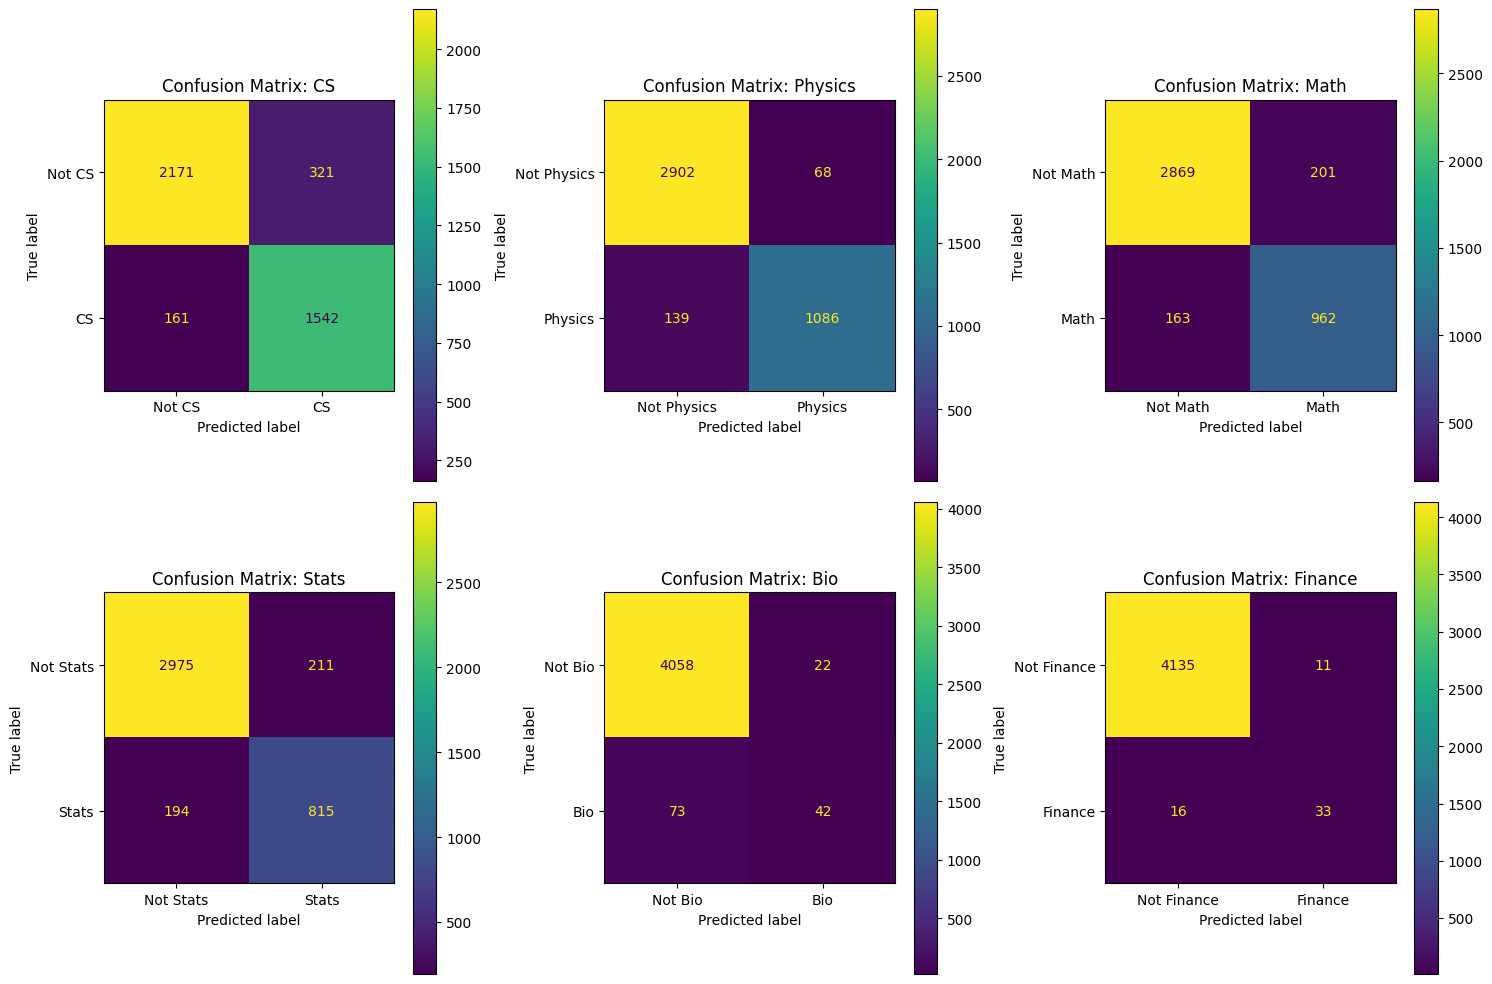

In [53]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mcm = multilabel_confusion_matrix(y_true, y_pred)
target_names = ['CS', 'Physics', 'Math', 'Stats', 'Bio', 'Finance']

# 3. Vẽ biểu đồ
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i],
                                  display_labels=[f"Not {target_names[i]}", target_names[i]])
    disp.plot(ax=axes[i], values_format='d', cmap='viridis')
    axes[i].set_title(f'Confusion Matrix: {target_names[i]}')

plt.tight_layout()
plt.show()


In [54]:
from transformers import AutoTokenizer

# 1. Khởi tạo tokenizer của model bạn định dùng
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

# 2. Kết hợp Title và Abstract
combined_texts = (df['TITLE'] + " " + df['ABSTRACT']).astype(str).tolist()

# 3. Đếm số lượng token cho từng bài
token_counts = [len(tokenizer.encode(text, add_special_tokens=True)) for text in combined_texts]

# 4. Thống kê kết quả
over_512 = sum(1 for count in token_counts if count > 512)
max_len = max(token_counts)
avg_len = sum(token_counts) / len(token_counts)

print(f"--- KẾT QUẢ KIỂM TRA SƠ BỘ ---")
print(f"Tổng số bài báo: {len(combined_texts)}")
print(f"Độ dài trung bình: {avg_len:.1f} tokens")
print(f"Độ dài lớn nhất: {max_len} tokens")
print(f"Số bài vượt quá giới hạn 512 của BERT: {over_512}")
print(f"Tỷ lệ mất mát thông tin: {(over_512 / len(combined_texts)) * 100:.2f}%")


--- KẾT QUẢ KIỂM TRA SƠ BỘ ---
Tổng số bài báo: 20972
Độ dài trung bình: 225.6 tokens
Độ dài lớn nhất: 927 tokens
Số bài vượt quá giới hạn 512 của BERT: 135
Tỷ lệ mất mát thông tin: 0.64%
